In [1]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import preparations as prep # dataset loading and definitions
import helper as hlp # helper functions for plotting and image processing
import importlib
importlib.reload(hlp)
importlib.reload(prep)

<module 'preparations' from '/content/preparations.py'>

In [2]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Importing Keras utility for image dataset loading
from keras.utils import image_dataset_from_directory

# Reporting t
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
# Variables
dataset_folder = os.path.join('..', 'dataset') # We stored the masked files in this dataset folder
class_normal = 'normal'
class_lung_opacity = 'lung_opacity'
class_viral_pneumonia = 'viral_pneumonia'
class_covid = 'covid'

### First try with Transfer Learning

##### Dataset loading and preprocessing

In [6]:
# For testing purposes, we try now loading all classes
batch_size = 16 # Rather small for fine grained learning rate

# First load the whole dataset with implicit resizing for VGG16
train_ds = image_dataset_from_directory(
    dataset_folder,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=batch_size,
    image_size=(224,224)        # Resize for compatibility with VGG16
)

val_ds = image_dataset_from_directory(
    dataset_folder,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=batch_size,
    image_size=(224,224)        # automatic resizing to the CNN input shape
)

# Check, which class names found (should be our 4 (or less for trials)) and save it for later use
class_names = train_ds.class_names.copy()
print(class_names)

# Adding optimization: caching and preloading
# This caused some errors, when only part of it is read, maybe switch it off
#train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
#val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Found 21165 files belonging to 4 classes.
Using 4233 files for validation.
['covid', 'lung_opacity', 'normal', 'viral_pneumonia']


In [7]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for image, _ in train_ds.take(1):
    print(image.shape)
    break

Number of batch in train_ds: 1059
Number of batch in val_ds: 265
(16, 224, 224, 3)


In [8]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'lung_opacity': 4847, 'normal': 8134, 'viral_pneumonia': 1048, 'covid': 2903}
Class Weights: {np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(3): 4.03912213740458, np.int32(0): 1.4581467447468137}


In [9]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

#### Try with VGG16 (imagenet pretrained)

In [10]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16

# VGG16 model
base_model = VGG16(weights='imagenet', include_top=False)

# Freeze the layers of VGG16
base_model.trainable = False

# Model creation using the Functional API
inputs = Input(shape=(224, 224, 3))

# Build the model
x = base_model(inputs)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

vgg16 = Model(inputs=inputs, outputs=outputs)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 3 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [12]:
# Compile with first idea of appropriate parameters
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
vgg16.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
from helper import model_summary_to_df
df_summary = model_summary_to_df(vgg16)
display(df_summary)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,766,852 (60.15 MB)

 Trainable params: 1,052,164 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_1 (InputLayer),"(None, 224, 224, 3)",0
1,vgg16 (Functional),"(None, 7, 7, 512)","14,714,688"
2,global_average_pooling2d,"(None, 512)",0
3,(GlobalAveragePooling2D),,
4,dense (Dense),"(None, 1024)","525,312"
5,dropout (Dropout),"(None, 1024)",0
6,dense_1 (Dense),"(None, 512)","524,800"
7,dropout_1 (Dropout),"(None, 512)",0
8,dense_2 (Dense),"(None, 4)","2,052"


In [13]:
# First training just on 10 batches (otherwise this would run endlessly on my machine)
history_model = vgg16.fit(train_ds,
                          epochs=25,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[early_stopping, reduce_learning_rate])

Epoch 1/25
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.6618 - loss: 0.9734 - val_accuracy: 0.7829 - val_loss: 0.5305 - learning_rate: 0.0010
Epoch 2/25
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7716 - loss: 0.4977 - val_accuracy: 0.7708 - val_loss: 0.5563 - learning_rate: 0.0010
Epoch 3/25
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7856 - loss: 0.4658 - val_accuracy: 0.8153 - val_loss: 0.4723 - learning_rate: 0.0010
Epoch 4/25
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7989 - loss: 0.4373 - val_accuracy: 0.8169 - val_loss: 0.4790 - learning_rate: 0.0010
Epoch 5/25
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.8035 - loss: 0.4214 - val_accuracy: 0.7954 - val_loss: 0.5312 - learning_rate: 0.0010
Epoch 6/25
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.8165 - loss: 0.3929 - val_accuracy: 0.8301 - val_loss: 0.4484 - learning_rate: 0.0010
Epoch 7/25
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accura

In [14]:
# Save the model for later use
if not os.path.exists(os.path.join('..', 'models')):
    os.makedirs(os.path.join('..', 'models'))
# Save the model in the models folder
model_name = '2a_vgg16_' + str(len(class_names)) + '-classes_dense512_masked.keras'
save_name = os.path.join('..', 'models', model_name)
vgg16.save(save_name)

##### Evalution

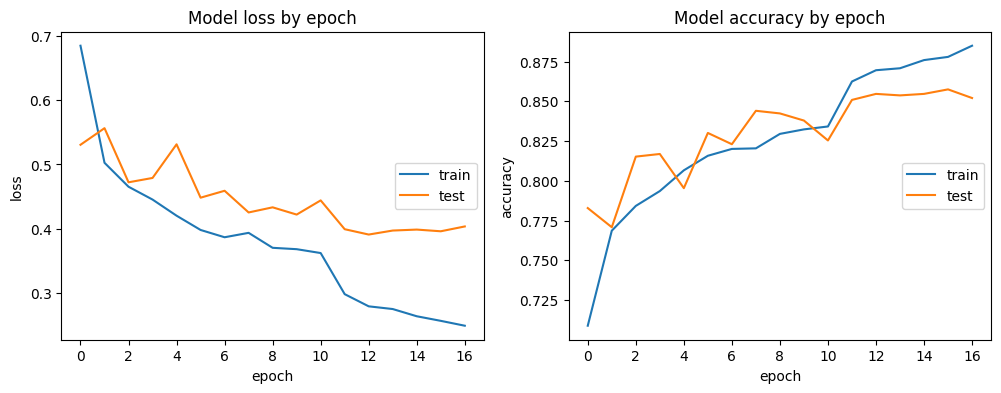

In [15]:
hlp.plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

In [16]:
y_true, y_pred = hlp.get_predictions_and_labels(vgg16, val_ds)

,pre,rec,spe,f1,geo,iba,sup
covid,0.712673,0.796634,0.934943,0.752318,0.863022,0.734506,713.000000
lung_opacity,0.838908,0.818026,0.940352,0.828336,0.877059,0.759822,1165.000000
normal,0.911899,0.875121,0.920000,0.893132,0.897280,0.801499,2058.000000
viral_pneumonia,0.876923,0.959596,0.989837,0.916399,0.974599,0.946972,297.000000
avg_pre,0.855799,0.855799,0.855799,0.855799,0.855799,0.855799,0.855799
avg_rec,0.852114,0.852114,0.852114,0.852114,0.852114,0.852114,0.852114
avg_spe,0.933018,0.933018,0.933018,0.933018,0.933018,0.933018,0.933018
avg_f1,0.853213,0.853213,0.853213,0.853213,0.853213,0.853213,0.853213
avg_geo,0.891369,0.891369,0.891369,0.891369,0.891369,0.891369,0.891369
avg_iba,0.788951,0.788951,0.788951,0.788951,0.788951,0.788951,0.788951


Predicted,covid,lung_opacity,normal,viral_pneumonia
covid,568,71,69,5
lung_opacity,115,953,97,0
normal,114,108,1801,35
viral_pneumonia,0,4,8,285


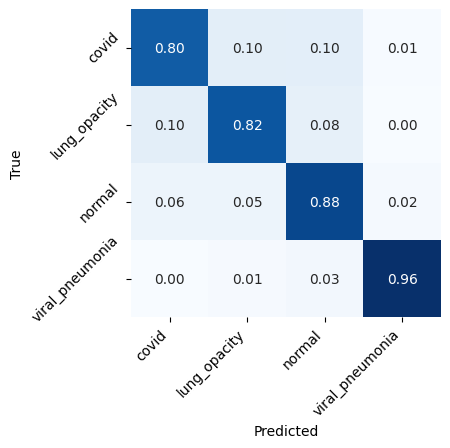

{'crosstab': Predicted        covid  lung_opacity  normal  viral_pneumonia
 covid              568            71      69                5
 lung_opacity       115           953      97                0
 normal             114           108    1801               35
 viral_pneumonia      0             4       8              285,
 'classification_report':                          pre          rec          spe           f1  \
 covid               0.712673     0.796634     0.934943     0.752318   
 lung_opacity        0.838908     0.818026     0.940352     0.828336   
 normal              0.911899     0.875121     0.920000     0.893132   
 viral_pneumonia     0.876923     0.959596     0.989837     0.916399   
 avg_pre             0.855799     0.855799     0.855799     0.855799   
 avg_rec             0.852114     0.852114     0.852114     0.852114   
 avg_spe             0.933018     0.933018     0.933018     0.933018   
 avg_f1              0.853213     0.853213     0.853213     0.853213   

In [17]:
hlp.report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes already not too bad
# However, the recall especially for the covid class is the lowest